# Explanation Eval EDA
개념 → 예시 → 실습 순서 구조 탐지를 위한 regex 패턴 탐색

In [221]:
import re
import glob
from pathlib import Path
from datetime import datetime, timedelta
import pandas as pd

## 1. 데이터 로드 및 파싱

In [222]:
KSS_PATH = Path("../data/processed/lectures_kss.csv")
print(f"KSS 경로: {KSS_PATH.resolve()}")
print(f"존재 여부: {KSS_PATH.exists()}")

KSS 경로: /Users/parkdahyeon/Documents/my_ws/Lecturesight-Lab/data/processed/lectures_kss.csv
존재 여부: True


In [223]:
df_raw = pd.read_csv(KSS_PATH)

df = df_raw.rename(columns={"text_raw": "text", "speaker_id": "speaker"}).copy()
df["dt"]   = pd.to_datetime(df["date"] + " " + df["timestamp"])
df["file"] = df["date"] + "_" + df["lecture_id"] + ".txt"
df = df.sort_values(["file", "dt"]).reset_index(drop=True)

print(f"전체 문장 수: {len(df):,}")
print(f"파일 수    : {df['file'].nunique()}")
df.head(3)

전체 문장 수: 24,238
파일 수    : 15


,lecture_id,date,timestamp,speaker,text,dt,file
0,kdt-backendj-21th,2026-02-02,01:00:30,b54f46b0,자 수업 진행하도 수업 시작하 저희가 이제 오전에 I이O 객체를 이용을 해서 파일의...,2026-02-02 01:00:30,2026-02-02_kdt-backendj-21th.txt
1,kdt-backendj-21th,2026-02-02,01:00:42,b54f46b0,이제 NIO2에 오시게 되면 자바가 가지고 있는 NIO에서 파일 객체 스트림을 지금...,2026-02-02 01:00:42,2026-02-02_kdt-backendj-21th.txt
2,kdt-backendj-21th,2026-02-02,01:01:05,b54f46b0,이런 거지,2026-02-02 01:01:05,2026-02-02_kdt-backendj-21th.txt


## 2. 레이블 탐지 Regex 정의

실제 텍스트 데이터를 보고 뽑은 키워드 기반

In [224]:
# ── [개념] ──────────────────────────────────────────────────────────────────
# 정의·원리·특징을 설명하는 발화
CONCEPT_PATTERNS = [
    # 정의형 선언 표현
    r"이라고 하는 것은",
    r"이라는 것은",
    r"이란 것은",
    r"이라는 뜻",
    r"이란 말이야",          # 구어체 정의 선언
    r"이라고 한다",
    r"이라고 합니다",
    r"이라고 얘기한다",
    r"이라고 얘기합니다",

    # # 수사의문 → 정의 답변 패턴
    # r"뭐냐면",
    # r"이게 뭐야",
    # r"[가이] 뭐야",

    # 개념·원리·특징 명시
    r"개념이",
    r"개념을",
    r"개념으로",
    r"원리가",
    r"원리는",
    r"특징이",
    r"특징은",
    r"특징을",
]

# ── [예시] ──────────────────────────────────────────────────────────────────
# 예시·비유·구체 사례를 드는 발화
EXAMPLE_PATTERNS = [
    # 예시 명시 (압도적 빈도)
    r"예를 들어서",
    r"예를 들면",
    r"예를 들어",
    r"예를 들자면",
    r"예를들면",
    r"예를들어",

    # 직접 비유 표현
    r"비유하면",
    r"비유를 하면",
    r"비유를 들면",
    r"비유를 들자면",
    r"이를테면",
    r"가령",
]

# ── [실습] ──────────────────────────────────────────────────────────────────
# 코드 작성·실행·IDE 조작 등 직접 수행을 유도하는 발화
PRACTICE_PATTERNS = [
    # 지시형 어미
    r"해보세요",
    r"해봐요",
    r"해보십시오",
    r"해보도록",
    r"해볼게요",
    r"해봐",

    # 코드 작성 지시
    r"코드를 작성",
    r"코드 작성",
    r"작성해보",
    r"코딩해보",
    r"코딩하면",
    r"코딩하겠",

    # 실행 지시
    r"실행해보",
    r"실행을 해보",
    r"실행해볼",
    r"한번 실행",

    # IDE 조작 (복사/붙이기)
    r"복사해서",
    r"붙여보",
    r"붙여보세요",
    r"붙여보십시오",

    # 직접 수행 명시
    r"직접 해보",
    r"직접 해봐",
    r"따라 해보",
    r"따라해보",
    r"따라오",

    # IDE 열기
    r"인텔리제이",
    r"이클립스",
    r"IDE",
]

def compile_patterns(patterns):
    combined = "|".join(f"(?:{p})" for p in patterns)
    return re.compile(combined)

concept_re  = compile_patterns(CONCEPT_PATTERNS)
example_re  = compile_patterns(EXAMPLE_PATTERNS)
practice_re = compile_patterns(PRACTICE_PATTERNS)

print("패턴 컴파일 완료")

패턴 컴파일 완료


## 3. 발화 단위 레이블링

In [225]:
def detect_labels(text):
    labels = []
    if concept_re.search(text):  labels.append("개념")
    if example_re.search(text):  labels.append("예시")
    if practice_re.search(text): labels.append("실습")
    return labels if labels else ["기타"]

df["labels"] = df["text"].apply(detect_labels)
df["is_개념"]  = df["labels"].apply(lambda l: "개념" in l)
df["is_예시"]  = df["labels"].apply(lambda l: "예시" in l)
df["is_실습"]  = df["labels"].apply(lambda l: "실습" in l)
df["is_기타"]  = df["labels"].apply(lambda l: l == ["기타"])

total = len(df)
print(f"전체 발화: {total:,}")
print(f"[개념] 히트: {df['is_개념'].sum():,} ({df['is_개념'].mean()*100:.1f}%)")
print(f"[예시] 히트: {df['is_예시'].sum():,} ({df['is_예시'].mean()*100:.1f}%)")
print(f"[실습] 히트: {df['is_실습'].sum():,} ({df['is_실습'].mean()*100:.1f}%)")
print(f"[기타] (패턴 없음): {df['is_기타'].sum():,} ({df['is_기타'].mean()*100:.1f}%)")

전체 발화: 24,238
[개념] 히트: 147 (0.6%)
[예시] 히트: 158 (0.7%)
[실습] 히트: 487 (2.0%)
[기타] (패턴 없음): 23,451 (96.8%)


## 4. Keyword-Anchored Chunking

키워드 히트 발화를 **anchor**로 삼아 앞 30초 + 뒤 210초 창을 생성하고, 겹치는 창은 병합. 쉬는시간(10분 이상 공백) 이후는 제외.

In [226]:
from datetime import timedelta

BEFORE_SEC    = 30
AFTER_SEC     = 210
BREAK_GAP_SEC = 600  # 발화 간 공백이 이 이상이면 쉬는시간으로 판단

## 5. LLM 분류 함수 정의 (Gemini)

- 모델: `gemini-2.5-flash`
- 입력: anchor 발화 + 전후 맥락
- 출력: label / reason / key_sentence (개념인 경우 정의 문장 인용)
- 실제 분류 실행은 **6번 섹션**에서 병합 후 수행

In [227]:
import google.generativeai as genai
import json
import asyncio
import os
from dotenv import load_dotenv
from tqdm.auto import tqdm

load_dotenv("../.env")
genai.configure(api_key=os.environ["GOOGLE_API_KEY"])

GEMINI_MODEL = "gemini-2.5-flash"

def make_prompt(anchor_text: str, chunk_text: str) -> str:
    return f"""다음은 한국어 강의 전사 텍스트입니다.
키워드가 탐지된 핵심 발화(ANCHOR)와 전후 약 3분 맥락(CONTEXT)을 함께 제공합니다.

[ANCHOR 발화]
{anchor_text}

[전후 맥락]
{chunk_text}

분류 기준:
- 개념: 텍스트에서 특정 용어·원리·특징을 **명시적으로** 정의하거나 설명하는 문장이 있어야 함
- 예시: "예를 들어", "비유하면" 등 표현과 함께 구체적 사례가 **실제로** 제시되어야 함
- 실습: 코드 작성·실행·IDE 조작 등 수행 지시가 **명확하게** 있어야 함
- 기타: 위 기준을 확실히 충족하는 증거가 없으면 **무조건 기타**

⚠️ 판단 지침:
- 애매하거나 억지로 끼워 맞춰야 한다면 → 기타
- 개념처럼 보여도 정의 문장이 명시적으로 없다면 → 기타
- 실습 키워드가 있어도 주변 맥락이 잡담이라면 → 기타

아래 JSON 형식으로만 응답하세요:
{{
  "label": "개념 또는 예시 또는 실습 또는 기타",
  "reason": "한 줄 판단 근거 (기타인 경우 증거가 없는 이유)",
  "key_sentence": "개념인 경우 텍스트에서 그대로 인용한 정의 문장, 아니면 null"
}}"""

async def classify_single(model, semaphore, pbar, idx, row):
    async with semaphore:
        try:
            response = await asyncio.to_thread(
                model.generate_content,
                make_prompt(row["anchor_text"], row["text"]),
                generation_config=genai.GenerationConfig(
                    response_mime_type="application/json"
                )
            )
            result = json.loads(response.text)
        except Exception as e:
            result = {"label": "ERROR", "reason": str(e), "key_sentence": None}
        finally:
            pbar.update(1)
        return {"idx": idx, **result}

async def run_classification(df_to_classify, concurrency=15):
    model = genai.GenerativeModel(GEMINI_MODEL)
    semaphore = asyncio.Semaphore(concurrency)
    pbar = tqdm(total=len(df_to_classify), desc="Gemini 분류 중")
    tasks = [
        classify_single(model, semaphore, pbar, idx, row)
        for idx, row in df_to_classify.iterrows()
    ]
    results = await asyncio.gather(*tasks)
    pbar.close()
    return results

print("설정 완료")


설정 완료


## 6. 창 크기 업데이트 + 겹치는 Anchor 병합 + LLM 분류

- AFTER_SEC: 150 → 210 (창 종료 후 발화가 93%에서 이어지는 것 확인)
- 겹치는 anchor 병합 후 LLM 재분류
- 쉬는시간(10분 이상 공백) 이후 발화 제외

In [228]:
from collections import Counter

def trim_window_at_break(window_df, break_gap_sec=BREAK_GAP_SEC):
    """창 내 발화 간 공백이 break_gap_sec 이상이면 그 직전까지만 반환"""
    if window_df.empty:
        return window_df
    window_sorted = window_df.sort_values("dt").reset_index(drop=True)
    gaps = window_sorted["dt"].diff().dt.total_seconds()
    break_idx = gaps[gaps >= break_gap_sec].index
    if break_idx.empty:
        return window_sorted
    return window_sorted.iloc[:break_idx[0]]

def make_anchored_chunks_merged(df, before_sec=BEFORE_SEC, after_sec=AFTER_SEC,
                                 break_gap_sec=BREAK_GAP_SEC):
    """
    1) 키워드 히트 발화를 anchor로 선정
    2) 창이 겹치는 연속 anchor를 병합 — 다음 anchor_dt <= 현재 창 종료 시각이면 창 확장
    3) 창 내 발화 간 공백이 break_gap_sec 이상이면 쉬는시간으로 판단, 직전까지만 포함
    """
    anchors = df[df["is_개념"] | df["is_예시"] | df["is_실습"]].copy()
    anchors = anchors.sort_values(["file", "dt"]).reset_index(drop=True)

    chunks = []
    for fname, group in anchors.groupby("file", sort=False):
        group = group.sort_values("dt").reset_index(drop=True)
        i = 0
        while i < len(group):
            cur = group.iloc[i]
            end_dt = cur["dt"] + timedelta(seconds=after_sec)

            j = i + 1
            merged_labels = [cur["labels"]]
            while j < len(group) and group.iloc[j]["dt"] <= end_dt:
                end_dt = group.iloc[j]["dt"] + timedelta(seconds=after_sec)
                merged_labels.append(group.iloc[j]["labels"])
                j += 1

            t0 = cur["dt"] - timedelta(seconds=before_sec)
            window = df[(df["file"] == fname) & (df["dt"] >= t0) & (df["dt"] <= end_dt)]
            window = trim_window_at_break(window, break_gap_sec)

            all_labels = [l for labels in merged_labels for l in labels if l != "기타"]
            anchor_label = Counter(all_labels).most_common(1)[0][0] if all_labels else "기타"

            chunks.append({
                "file":         fname,
                "anchor_dt":    cur["dt"],
                "anchor_label": anchor_label,
                "anchor_text":  cur["text"],
                "n_merged":     j - i,
                "n_utterances": len(window),
                "text":         " ".join(window["text"].tolist()),
            })
            i = j

    return pd.DataFrame(chunks)

anchored_v2 = make_anchored_chunks_merged(df)

print(f"병합 후 청크 수: {len(anchored_v2):,}")
print(f"병합된 청크(n_merged >= 2): {(anchored_v2['n_merged'] >= 2).sum()}개")
print()
print(anchored_v2["anchor_label"].value_counts())
print()
print(f"청크당 평균 발화 수: {anchored_v2['n_utterances'].mean():.1f}")

병합 후 청크 수: 385
병합된 청크(n_merged >= 2): 191개

anchor_label
실습    257
예시     66
개념     62
Name: count, dtype: int64

청크당 평균 발화 수: 31.9


In [229]:
# ── 병합된 청크 LLM 재분류 ──────────────────────────────────────────────────
all_results_v2 = await run_classification(anchored_v2, concurrency=15)

results_v2 = pd.DataFrame(all_results_v2).set_index("idx")
anchored_v2["llm_label"]        = results_v2["label"]
anchored_v2["llm_reason"]       = results_v2["reason"]
anchored_v2["llm_key_sentence"] = results_v2["key_sentence"]

print("=== LLM 재분류 결과 (병합 후) ===")
print(anchored_v2["llm_label"].value_counts())
print()
print("=== Regex anchor → LLM 혼동 행렬 ===")
print(pd.crosstab(anchored_v2["anchor_label"], anchored_v2["llm_label"], margins=True))

Gemini 분류 중: 100%|██████████| 385/385 [03:44<00:00,  1.71it/s]

=== LLM 재분류 결과 (병합 후) ===
llm_label
실습    188
개념     83
예시     72
기타     42
Name: count, dtype: int64

=== Regex anchor → LLM 혼동 행렬 ===
llm_label     개념  기타   실습  예시  All
anchor_label                      
개념            46  12    1   3   62
실습            29  29  184  15  257
예시             8   1    3  54   66
All           83  42  188  72  385


In [230]:
OUT_PATH = "../data/anchored_labeled.json"

save_cols = [
    "file", "anchor_dt", "anchor_label", "n_merged",
    "anchor_text", "n_utterances", "text",
    "llm_label", "llm_reason", "llm_key_sentence",
]
anchored_v2[save_cols].to_json(OUT_PATH, orient="records", indent=2, force_ascii=False, date_format="iso")
print(f"저장 완료: {OUT_PATH}  ({len(anchored_v2):,}행)")

저장 완료: ../data/anchored_labeled.json  (385행)


---
# EDA

## 9. [EDA] Anchored 청크 샘플 확인

`make_anchored_chunks`로 병합 없이 생성한 원본 anchored_df 기준

In [231]:
from collections import Counter

def make_anchored_chunks(df, before_sec=BEFORE_SEC, after_sec=AFTER_SEC):
    anchors = df[df["is_개념"] | df["is_예시"] | df["is_실습"]].copy()
    anchors = anchors.sort_values(["file", "dt"]).reset_index(drop=True)

    chunks = []
    for _, anchor in anchors.iterrows():
        t0 = anchor["dt"] - timedelta(seconds=before_sec)
        t1 = anchor["dt"] + timedelta(seconds=after_sec)
        window = df[(df["file"] == anchor["file"]) & (df["dt"] >= t0) & (df["dt"] <= t1)]

        hit_labels = [l for l in anchor["labels"] if l != "기타"]
        chunks.append({
            "file":         anchor["file"],
            "anchor_dt":    anchor["dt"],
            "anchor_label": hit_labels[0] if hit_labels else "기타",
            "anchor_text":  anchor["text"],
            "n_utterances": len(window),
            "text":         " ".join(window["text"].tolist()),
        })

    return pd.DataFrame(chunks)

anchored_df = make_anchored_chunks(df)
print(f"Anchored 청크 수: {len(anchored_df):,}")
print(anchored_df["anchor_label"].value_counts())

Anchored 청크 수: 787
anchor_label
실습    483
예시    157
개념    147
Name: count, dtype: int64


In [232]:
# anchor 청크 샘플 확인 — anchor_text(키워드 발화)와 주변 맥락
def show_anchored_sample(label, n=3):
    sample = anchored_df[anchored_df["anchor_label"] == label].sample(n=min(n, len(anchored_df)), random_state=42)
    for _, row in sample.iterrows():
        print(f"[{row['file']} @ {row['anchor_dt'].strftime('%H:%M:%S')}]")
        print(f"  ANCHOR: {row['anchor_text']}")
        print(f"  WINDOW({row['n_utterances']}발화): {row['text'][:200]}...")
        print()

print("=== [개념] anchored 청크 샘플 ===")
show_anchored_sample("개념")

print("=== [예시] anchored 청크 샘플 ===")
show_anchored_sample("예시")

=== [개념] anchored 청크 샘플 ===
[2026-02-27_kdt-backendj-21th.txt @ 01:54:45]
  ANCHOR: 이게 지금 추상적인 반영이라는 뜻이야 데이터 관점을 재구성한 구제라는 뜻이에요.
  WINDOW(34발화): 됐든 모르겠네 어쨌든 좀 살짝 지우고 다시 핵심 요소를 추출하는 추상적 반영이다. 이 자체가 어떤 고객이 있어 아니면 나 사원이 있어 사원이 있으면 여기 사원이야 동그라미 엔티T 형식으로 그린다고 그래서 여기서 맨 처음에 속성들을 이렇게 뽑아와 이렇게 사원의 이름 사원 번호 사리야 이렇게 뽑아오는 거 있지 이게 지금 추상적인 반영이라는 뜻이야 데이터 관점을...

[2026-02-10_kdt-backendj-21th.txt @ 09:24:25]
  ANCHOR: 이런 것들 한눈에 보시면 어쨌든 그리하여 시조인이라고 하는 것은 표준조인이다.
  WINDOW(34발화): 그래서 입이 끝날 때쯤 휴가 전에 23일 나눠드리면, 그때 아 이 DB는 이렇게 생겼고 저 DB는 저렇게 생겼구나를 조금 비교해서 여러분들이 회고시간에 습득하시게끔 정리를 하고 있거든요. 그래서 보면 포스트 그린데도 안C 조인이 잘 되고 IS클인데도 안C 조인이 잘 되는구나. 그 다음에 신기하게도 노에스큐L도 약간의 조인의 개념이 있구나 이런 것들 한눈에 ...

[2026-02-27_kdt-backendj-21th.txt @ 09:34:39]
  ANCHOR: 그래서 내가 받겠다라는 개념이 익스포트하고는 입장이 조금 달라요.
  WINDOW(29발화): 아 일단은 덤프는 가만히 생각을 해보면 여기가 나의 위치잖아요. 그런데 여기가 여러분들이 가지고 있는 위치란 말이야. 여기 저는 지금 여기서 복사한 게 지금 여기니까 이렇게 지금 명령을 수행하고 있죠. 그러면 현재 나의 위치예요. 그럼 얘가 지금 내가 있는 위치야 이 덤프라고 하는 것은 내가 있는 위치에서 서버에 접속한 애를 내려받겠다는 개념이에요. 그래서...

=== [예시] anchor

In [233]:
def inspect_anchored_chunks(label=None, file=None, n=5, random_state=42):
    """
    anchored_df 청크를 읽기 좋게 출력.
    label: "개념" | "예시" | "실습" | None (전체)
    file: 특정 파일명 필터 (None이면 전체)
    n: 출력할 청크 수
    """
    subset = anchored_df.copy()
    if label:
        subset = subset[subset["anchor_label"] == label]
    if file:
        subset = subset[subset["file"] == file]

    sample = subset.sample(n=min(n, len(subset)), random_state=random_state)

    for i, (_, row) in enumerate(sample.iterrows(), 1):
        print(f"{'='*70}")
        print(f"[{i}] {row['file']}  @  {row['anchor_dt'].strftime('%H:%M:%S')}  |  anchor: [{row['anchor_label']}]")
        print(f"{'─'*70}")
        print(f"▶ ANCHOR  : {row['anchor_text']}")
        print(f"{'─'*70}")

        # 창 안 발화를 원본 df에서 다시 꺼내서 한 줄씩 출력
        t0 = row["anchor_dt"] - timedelta(seconds=BEFORE_SEC)
        t1 = row["anchor_dt"] + timedelta(seconds=AFTER_SEC)
        window = df[
            (df["file"] == row["file"]) &
            (df["dt"] >= t0) &
            (df["dt"] <= t1)
        ].sort_values("dt")

        for _, utt in window.iterrows():
            marker = "★" if utt["text"] == row["anchor_text"] else "  "
            print(f"{marker} {utt['dt'].strftime('%H:%M:%S')}  {utt['text']}")

        print()

# ── 사용 예시 ─────────────────────────────────────────────────────────────
# label / file / n / random_state 자유롭게 바꿔서 확인
inspect_anchored_chunks(label="예시", n=20)

[1] 2026-02-24_kdt-backendj-21th.txt  @  10:23:33  |  anchor: [예시]
──────────────────────────────────────────────────────────────────────
▶ ANCHOR  : 이렇게 그래서 얘는 뭐 많이 없으니까 제가 여기 살짝 적어드리면, 로우 카운트는 저희가 여기는 언더 저희가 있고 영향을 받은 행의 수 그러니까 예를 들자면 인서트나 업데이트할 때 나는 거 인서트 할 때 업데이트 할 때 나는 넘버는 에러가 몇 개 났는지 계수야 그렇지 로우 카운트가 에러 계수인 줄 알았는데 여긴 넘버가 에러 계수야 데이트하고 딜리트 했을 때 된 개수 실행계수 이게 왜 인서트 3개 했으면 3 로우라고 리턴해주잖아요.
──────────────────────────────────────────────────────────────────────
   10:23:15  자 그 다음에 지금 이제 여기 있는 여기 이 부분 이 부분 섹션 점점 되어있는 부분 이거는 실행 전체 정보야 실행 전체 정보인데 보통 이제 넘버랑 로우 카운트를 이용을 해서 리턴을 해줘요
★ 10:23:33  이렇게 그래서 얘는 뭐 많이 없으니까 제가 여기 살짝 적어드리면, 로우 카운트는 저희가 여기는 언더 저희가 있고 영향을 받은 행의 수 그러니까 예를 들자면 인서트나 업데이트할 때 나는 거 인서트 할 때 업데이트 할 때 나는 넘버는 에러가 몇 개 났는지 계수야 그렇지 로우 카운트가 에러 계수인 줄 알았는데 여긴 넘버가 에러 계수야 데이트하고 딜리트 했을 때 된 개수 실행계수 이게 왜 인서트 3개 했으면 3 로우라고 리턴해주잖아요.
   10:24:17  지금 현재 거기에 있는 로우 언더바 카운트 그래서 실행 전체 정보를 통계로 보여줘 통계지표 이렇게 생각하시면 되고 그다음에 얘 같은 경우에는 얘네들 있죠.
   10:24:34  이렇게가 지금 OR에서 포디션을 뒤에 세트로 이렇게 되어 있잖아.
   10:24:36  이거

## 10. [EDA] 파일별 개념/예시/실습 분포 시각화

LLM 검증 결과를 타임라인으로 표시. 각 점 = anchored 청크, 색상 = llm_label.

In [234]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
matplotlib.rc("font", family="AppleGothic")
plt.rcParams["axes.unicode_minus"] = False

LABEL_COLOR = {"개념": "#4C72B0", "예시": "#DD8452", "실습": "#55A868", "기타": "#CCCCCC"}
LABEL_Y     = {"개념": 3, "예시": 2, "실습": 1, "기타": 0}

def plot_file_distribution(target_file: str):
    subset = anchored_v2[anchored_v2["file"] == target_file].copy()
    if subset.empty:
        print(f"{target_file}: 데이터 없음")
        return

    t0 = subset["anchor_dt"].min()
    subset["minutes"] = (subset["anchor_dt"] - t0).dt.total_seconds() / 60

    fig, ax = plt.subplots(figsize=(16, 3.5))

    for _, row in subset.iterrows():
        label = row.get("llm_label", row["anchor_label"])
        color = LABEL_COLOR.get(label, "#CCCCCC")
        y     = LABEL_Y.get(label, 0)
        ax.scatter(row["minutes"], y, color=color, s=120, alpha=0.85, zorder=3)

        if label == "개념" and row.get("llm_key_sentence"):
            ax.annotate(
                str(row["llm_key_sentence"])[:30] + "…",
                (row["minutes"], y),
                textcoords="offset points", xytext=(0, 8),
                fontsize=6, color="#4C72B0", rotation=45, ha="left"
            )

    ax.set_yticks(list(LABEL_Y.values()))
    ax.set_yticklabels(list(LABEL_Y.keys()), fontsize=11)
    ax.set_xlabel("강의 경과 시간 (분)", fontsize=11)
    ax.set_title(target_file, fontsize=12)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.set_xlim(-2, subset["minutes"].max() + 5)

    legend = [mpatches.Patch(color=c, label=l) for l, c in LABEL_COLOR.items()]
    ax.legend(handles=legend, loc="upper right", fontsize=10)

    plt.tight_layout()
    plt.show()
    print(f"총 {len(subset)}개 anchor  |  {subset['llm_label'].value_counts().to_dict()}")

print("사용 가능한 파일:")
for i, f in enumerate(sorted(anchored_v2["file"].unique())):
    print(f"  [{i:>2}] {f}")

사용 가능한 파일:
  [ 0] 2026-02-02_kdt-backendj-21th.txt
  [ 1] 2026-02-03_kdt-backendj-21th.txt
  [ 2] 2026-02-04_kdt-backendj-21th.txt
  [ 3] 2026-02-05_kdt-backendj-21th.txt
  [ 4] 2026-02-06_kdt-backendj-21th.txt
  [ 5] 2026-02-09_kdt-backendj-21th.txt
  [ 6] 2026-02-10_kdt-backendj-21th.txt
  [ 7] 2026-02-11_kdt-backendj-21th.txt
  [ 8] 2026-02-12_kdt-backendj-21th.txt
  [ 9] 2026-02-13_kdt-backendj-21th.txt
  [10] 2026-02-23_kdt-backendj-21th.txt
  [11] 2026-02-24_kdt-backendj-21th.txt
  [12] 2026-02-25_kdt-backendj-21th.txt
  [13] 2026-02-26_kdt-backendj-21th.txt
  [14] 2026-02-27_kdt-backendj-21th.txt


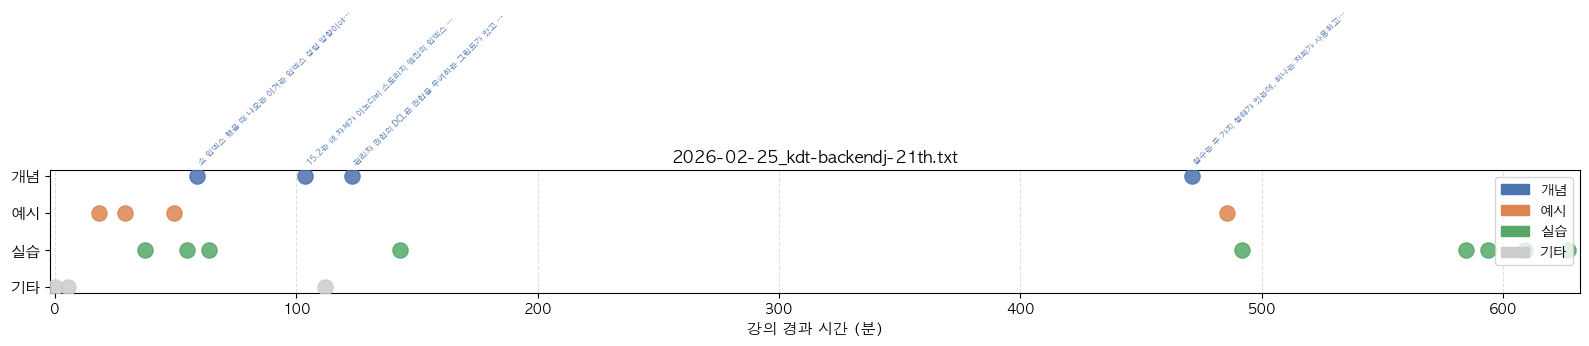

총 20개 anchor  |  {'실습': 9, '예시': 4, '개념': 4, '기타': 3}


In [235]:
plot_file_distribution("2026-02-25_kdt-backendj-21th.txt")

# 설명 순서 평가